In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import shap
import eli5

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import networkx as nx
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


In [2]:


d = {}
d["f1"] = np.random.randn(800)
d["f2"] = d["f1"]*10 + np.random.randn(800)*0.1
for i in range(3, 6):
    d[f"f{i}"] = np.random.randn(800)
d["f6"] = 0.6*d["f1"] + 0.6*d["f2"]

df = pd.DataFrame(d)


df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      800 non-null    float64
 1   f2      800 non-null    float64
 2   f3      800 non-null    float64
 3   f4      800 non-null    float64
 4   f5      800 non-null    float64
 5   f6      800 non-null    float64
dtypes: float64(6)
memory usage: 37.6 KB


/var/folders/v3/4s04_5rd42558r4rq9nh54_80000gn/T/ipykernel_3768/3057654078.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


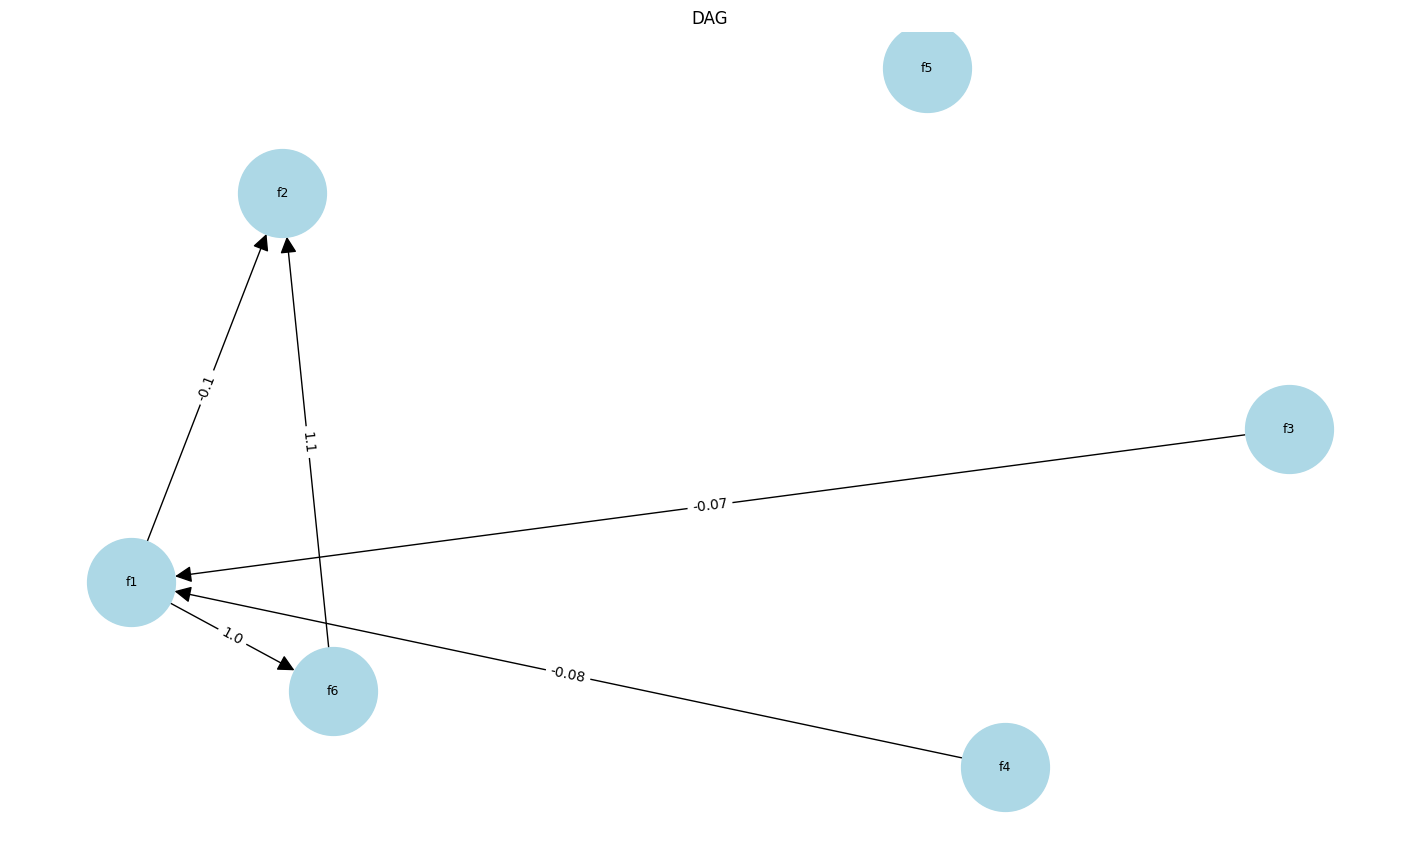

In [3]:

cols= ["f1","f2", "f3", "f4", "f5", "f6"]

def graph2(df, cols):


    imputer = SimpleImputer(strategy='median')
    X_clean = pd.DataFrame(imputer.fit_transform(df[cols]), columns=cols)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=cols)


    binary_data = X_clean[[c for c in cols if c.startswith('IN_')]]
    non_binary_data = X_clean[[c for c in cols if not c.startswith('IN_')]]


    #rex
    def rex_algorithm(data_df):
        X = data_df.values.copy()
        names = data_df.columns.tolist()
        n = len(names)
        remaining = list(range(n))
        order = []
        
        #iterate
        while len(remaining) > 0:
            scores = []
            for i in remaining:
                total_dep= 0
                xi = X[:, i].reshape(-1, 1)
                for j in remaining:
                    if i == j: continue
                    xj = X[:, j].reshape(-1, 1)
                    lr = LinearRegression().fit(xi,xj)
                    residual = xj - lr.predict(xi)
                    total_dep += abs(np.corrcoef(xi.flatten(), residual.flatten())[0,1])
                scores.append((total_dep, i))
            
            scores.sort()
            best_root = scores[0][1]
            order.append(best_root)
            remaining.remove(best_root)
            if len(remaining) >0:
                xi_root = X[:, best_root].reshape(-1, 1)
                for j in remaining:
                    xj = X[:,j].reshape(-1, 1)
                    lr = LinearRegression().fit(xi_root, xj)
                    X[:, j] = (xj - lr.predict(xi_root)).flatten()
                    
        return [names[i] for i in order]

    causal_order = rex_algorithm(X_scaled)

    B = pd.DataFrame(0.0, index=cols, columns=cols)
    X_std_df = pd.DataFrame(X_scaled, columns=cols)

    for i, target in enumerate(causal_order):
        if i == 0: continue
        parents = causal_order[:i]
        
        y = X_std_df[target]
        X_p = X_std_df[parents]
        
        reg = LinearRegression().fit(X_scaled[parents], X_scaled[target])
        for p_idx, p_name in enumerate(parents):
            B.loc[target, p_name] = reg.coef_[p_idx]


    B_pruned= B.copy()
    B_pruned[np.abs(B_pruned) < 0.05] =0

    dico = {node: [] for node in cols}
    G= nx.DiGraph()
    for node in cols:
        G.add_node(node)
        

    for row in B_pruned.index:
        for col in B_pruned.columns:
            if B_pruned.loc[row, col]!= 0:
                G.add_edge(col, row, weight=round(B_pruned.loc[row, col], 2))
                dico[row].append((col, round(B_pruned.loc[row, col], 2)))


    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, k=2)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=4000, font_size=9, arrowsize=25)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("DAG")
    plt.tight_layout()
    plt.savefig('rex_causal_dag.png')

    return dico

graph=graph2(df, cols)

In [4]:


def boostrap(df, cols, n_iterations=50):
    all_edges={}
    for i in range(n_iterations):
        df_sample = resample(df[cols], n_samples=len(df)//2) 
        current_dico = graph2(df_sample, cols) 
        for parent in current_dico.keys():
            for child, weight in current_dico[parent]:
                edge = (parent, child)
                if edge not in all_edges:
                    all_edges[edge] = []
                all_edges[edge].append(weight)

    robust_links = []
    for edge, weights in all_edges.items():
        confidence = len(weights) /n_iterations
        if confidence >= 0.40:
            avg_weight = np.mean(weights)
            robust_links.append({'cause': edge[0], 'effet': edge[1], 
                                 'confiance': confidence, 'poidsmoyen': avg_weight})
            
    return pd.DataFrame(robust_links)


#res=boostrap(df, cols, n_iterations=50)



def draw_robust_graph(df_robust):
    G = nx.DiGraph()
    for _, row in df_robust.iterrows():
        G.add_edge(
            row['cause'], 
            row['effet'], 
            weight=row['poidsmoyen'], 
            confiance=row['confiance']
        )

    fig, ax = plt.subplots(figsize=(15, 11))
    pos = nx.spring_layout(G, k=3, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=5000, node_color='white', edgecolors='black', linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    for u, v, d in G.edges(data=True):
        color = 'blue' if d['weight'] > 0 else 'red'
        width = abs(d['weight']) * 6 + 1
        alpha = d['confiance']

        rad = 0.2 if G.has_edge(v, u) else 0.0
        ax.annotate("",
                    xy=pos[v], xycoords='data',
                    xytext=pos[u], textcoords='data',
                    arrowprops=dict(
                        arrowstyle="->,head_width=0.5,head_length=0.8",
                        color=color,
                        shrinkA=30,
                        shrinkB=30,
                        connectionstyle=f"arc3,rad={rad}",
                        linewidth=width, 
                        alpha=alpha,
                        mutation_scale=30 ))




# ok, we have a problem: the rex sees noise as dependancies and does not account for linear dependencies

## need to think about an other algo

ideas: non-gaussianity of data => LinGAM
predicting data => but prediction != intervention

idea: HSIC

/var/folders/v3/4s04_5rd42558r4rq9nh54_80000gn/T/ipykernel_3768/4145480104.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


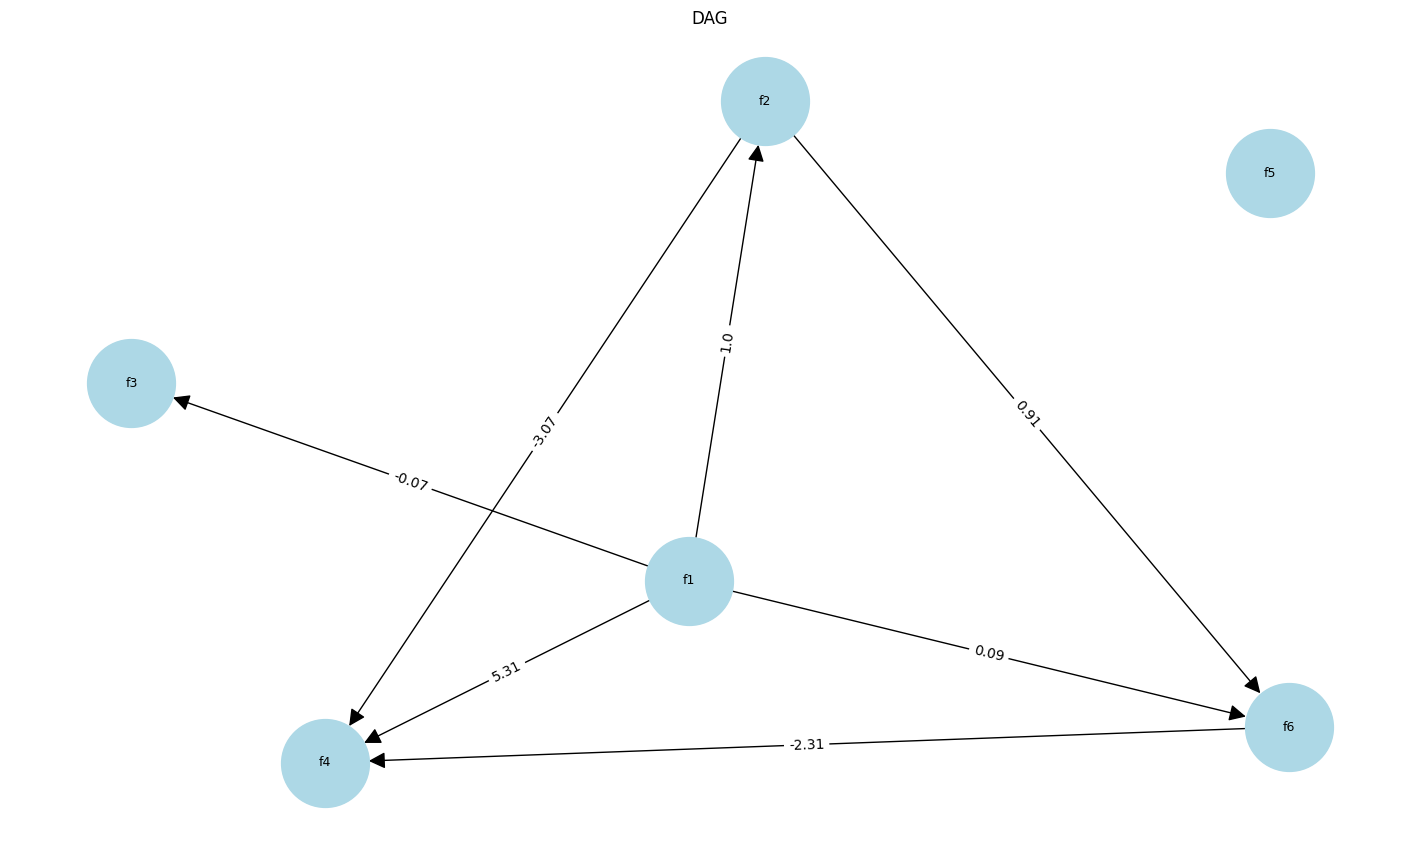

In [5]:

cols= ["f1","f2", "f3", "f4", "f5", "f6"]

def graph2(df, cols):


    imputer = SimpleImputer(strategy='median')
    X_clean = pd.DataFrame(imputer.fit_transform(df[cols]), columns=cols)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=cols)


    binary_data = X_clean[[c for c in cols if c.startswith('IN_')]]
    non_binary_data = X_clean[[c for c in cols if not c.startswith('IN_')]]


    #rex
    def rex_algorithm_upgraded(data_df):
        X_orig = data_df.values.copy()
        names = data_df.columns.tolist()
        n = len(names)
        remaining = list(range(n))
        order = []
     
        X = X_orig.copy()

        while len(remaining) > 0:
            scores = []
            for i in remaining:
                independence_violation = 0
                xi = X[:, i].reshape(-1, 1)
                
                for j in remaining:
                    if i == j: continue
                    xj = X[:, j].reshape(-1, 1)

                    lr = LinearRegression().fit(xi, xj)
                    residual = xj - lr.predict(xi)

                    res_centered = residual.flatten() - np.mean(residual)
                    xi_flattened = xi.flatten()

                    stat_dep = (
                        abs(np.corrcoef(xi_flattened, res_centered**2)[0, 1]) + 
                        abs(np.corrcoef(xi_flattened, np.tanh(res_centered))[0, 1])
                    )
                    independence_violation += stat_dep
                
                scores.append((independence_violation, i))
            

            scores.sort() 
            best_root = scores[0][1]
            order.append(best_root)
            remaining.remove(best_root)
            

            if len(remaining) > 0:
                xi_root = X[:, best_root].reshape(-1, 1)
                for j in remaining:
                    xj = X[:, j].reshape(-1, 1)
                    lr = LinearRegression().fit(xi_root, xj)
                    X[:, j] = (xj - lr.predict(xi_root)).flatten()
                    
        return [names[i] for i in order]

    causal_order = rex_algorithm_upgraded(X_scaled)

    B = pd.DataFrame(0.0, index=cols, columns=cols)
    X_std_df = pd.DataFrame(X_scaled, columns=cols)

    for i, target in enumerate(causal_order):
        if i == 0: continue
        parents = causal_order[:i]
        
        y = X_std_df[target]
        X_p = X_std_df[parents]
        
        reg = LinearRegression().fit(X_scaled[parents], X_scaled[target])
        for p_idx, p_name in enumerate(parents):
            B.loc[target, p_name] = reg.coef_[p_idx]


    B_pruned= B.copy()
    B_pruned[np.abs(B_pruned) < 0.05] =0

    dico = {node: [] for node in cols}
    G= nx.DiGraph()
    for node in cols:
        G.add_node(node)
        

    for row in B_pruned.index:
        for col in B_pruned.columns:
            if B_pruned.loc[row, col]!= 0:
                G.add_edge(col, row, weight=round(B_pruned.loc[row, col], 2))
                dico[row].append((col, round(B_pruned.loc[row, col], 2)))


    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, k=2)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=4000, font_size=9, arrowsize=25)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("DAG")
    plt.tight_layout()
    plt.savefig('rex_causal_dag.png')

    return dico

graph=graph2(df, cols)